In [15]:
import numpy as np
import matplotlib.pyplot as plt

pc = 3.085677581e18        # cm
Myr = 3.15576e13          # s
m_H = 1.6735575e-24     # g
G = 6.67430e-8          # cgs
mu = 2.33              # molecular gas mean molecular weight
beta = 1.15              # Sedov-Taylor constant for gamma = 5/3

def rho_from_n(n):
    """
    Convert number density in cm^-3 to mass density in g/cm^3.
    """
    return mu * m_H * n

def sedov_hit_time(D_pc, E_erg, n_amb):
    """
    Time for the Sedov-Taylor blast wave to reach distance D.
    """
    D = D_pc * pc
    rho_amb = rho_from_n(n_amb)
    t = (D / beta)**(5/2) * (rho_amb / E_erg)**0.5
    return t

def shock_velocity_at_distance(D_pc, E_erg, n_amb):
    """
    Shock velocity when the blast wave reaches distance D.
    """
    D = D_pc * pc
    t_hit = sedov_hit_time(D_pc, E_erg, n_amb)
    v_s = (2/5) * D / t_hit
    return v_s

def cloud_crushing_time(Rc_pc, n_cloud, n_amb, D_pc, E_erg):
    """
    Cloud crushing time:
    t_cc = sqrt(chi) * R_c / v_s
    """
    Rc = Rc_pc * pc
    chi = n_cloud / n_amb
    v_s = shock_velocity_at_distance(D_pc, E_erg, n_amb)
    t_cc = np.sqrt(chi) * Rc / v_s
    return t_cc

def freefall_time(n_cloud):
    """
    Free-fall time for a uniform-density cloud.
    """
    rho_c = rho_from_n(n_cloud)
    tff = np.sqrt(3 * np.pi / (32 * G * rho_c))
    return tff

In [16]:
Rc_pc = 10
n_cloud = 1000
n_amb = 1
D_pc = 30
E_erg = 1e51

tcc = cloud_crushing_time(Rc_pc, n_cloud, n_amb, D_pc, E_erg)
tff = freefall_time(n_cloud)

print("Cloud crushing time:", tcc / Myr, "Myr")
print("Free-fall time:", tff / Myr, "Myr")
print("Ratio t_cc/t_ff:", tcc / tff)

Cloud crushing time: 3.031432939837568 Myr
Free-fall time: 1.06599573207812 Myr
Ratio t_cc/t_ff: 2.843757107664868


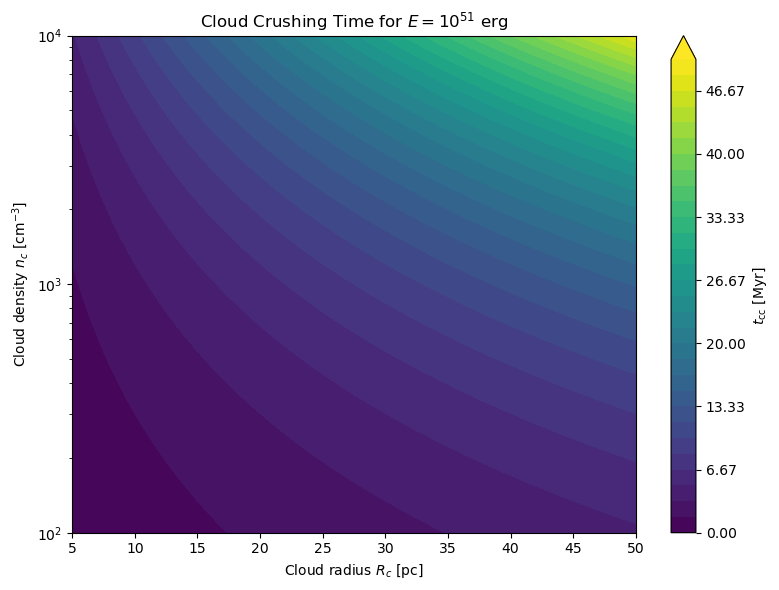

In [17]:

levels = np.linspace(0, 50, 31)  
R_vals = np.linspace(5, 50, 100)             
n_vals = np.logspace(2, 4, 100)             

R_grid, n_grid = np.meshgrid(R_vals, n_vals)

n_amb = 1.0
D_pc = 30.0
E_erg = 1e51

tcc_grid = cloud_crushing_time(R_grid, n_grid, n_amb, D_pc, E_erg) / Myr

levels = np.linspace(0, 50, 31)

plt.figure(figsize=(8, 6))
cont = plt.contourf(R_grid, n_grid, tcc_grid, levels=levels, extend="max")
plt.yscale("log")
plt.colorbar(cont, label=r"$t_{\rm cc}$ [Myr]")
plt.xlabel(r"Cloud radius $R_c$ [pc]")
plt.ylabel(r"Cloud density $n_c$ [cm$^{-3}$]")
plt.title(r"Cloud Crushing Time for $E = 10^{51}$ erg")
plt.tight_layout()
plt.show()

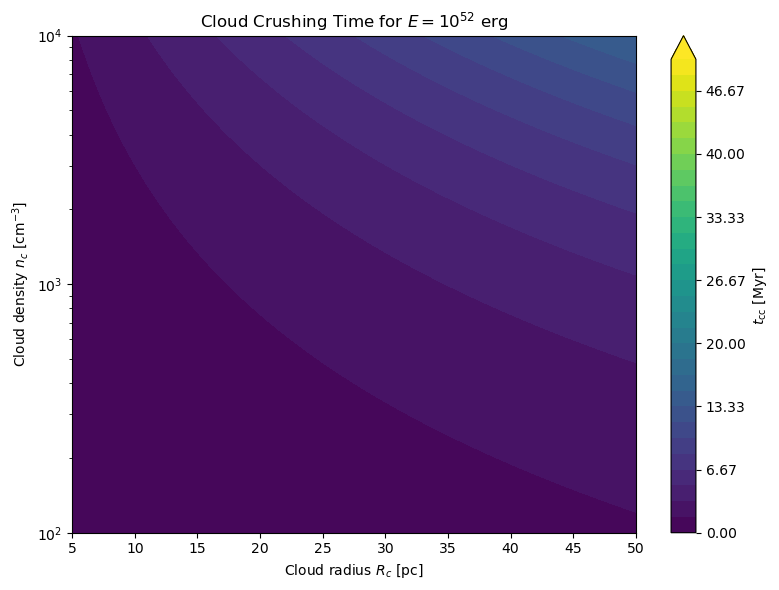

In [18]:
E_erg = 1e52
tcc_grid_highE = cloud_crushing_time(R_grid, n_grid, n_amb, D_pc, E_erg) / Myr

levels = np.linspace(0, 50, 31)

plt.figure(figsize=(8, 6))
cont = plt.contourf(
    R_grid, 
    n_grid, 
    tcc_grid_highE, 
    levels=levels, 
    extend="max"
)

plt.yscale("log")
plt.colorbar(cont, label=r"$t_{\rm cc}$ [Myr]")
plt.xlabel(r"Cloud radius $R_c$ [pc]")
plt.ylabel(r"Cloud density $n_c$ [cm$^{-3}$]")
plt.title(r"Cloud Crushing Time for $E = 10^{52}$ erg")
plt.tight_layout()
plt.show()

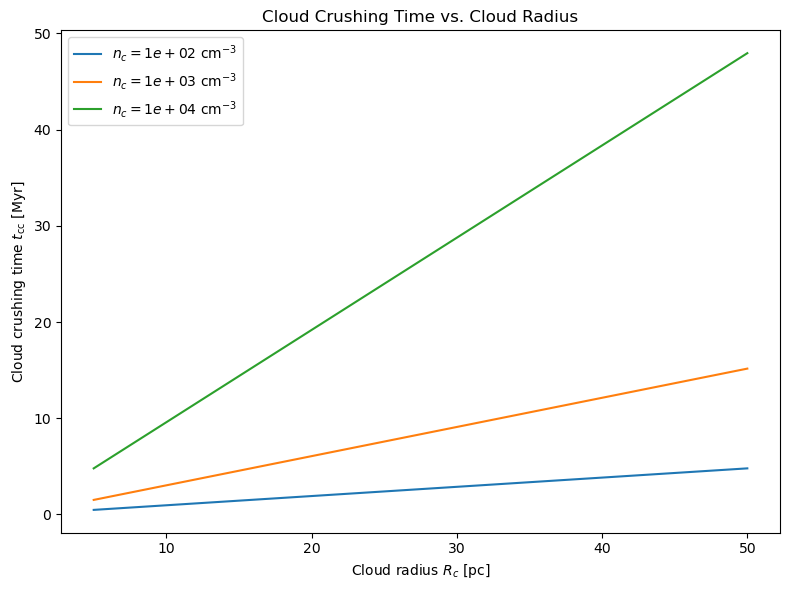

In [19]:
R_vals = np.linspace(5, 50, 100)
n_cloud_list = [1e2, 1e3, 1e4]

n_amb = 1.0
D_pc = 30.0
E_erg = 1e51

plt.figure(figsize=(8, 6))

for n_cloud in n_cloud_list:
    tcc_vals = cloud_crushing_time(R_vals, n_cloud, n_amb, D_pc, E_erg) / Myr
    plt.plot(R_vals, tcc_vals, label=rf"$n_c = {n_cloud:.0e}$ cm$^{{-3}}$")

plt.xlabel(r"Cloud radius $R_c$ [pc]")
plt.ylabel(r"Cloud crushing time $t_{\rm cc}$ [Myr]")
plt.title(r"Cloud Crushing Time vs. Cloud Radius")
plt.legend()
plt.tight_layout()
plt.show()

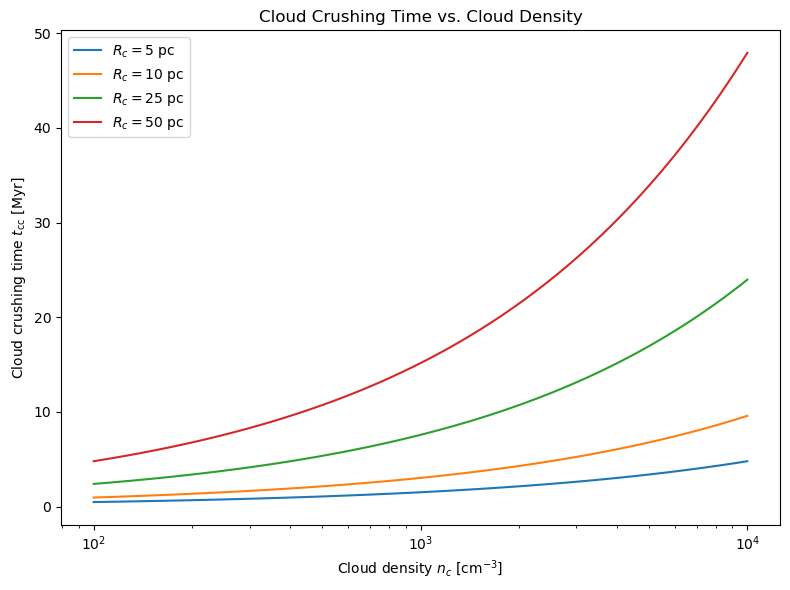

In [20]:
n_vals = np.logspace(2, 4, 100)
R_cloud_list = [5, 10, 25, 50]

n_amb = 1.0
D_pc = 30.0
E_erg = 1e51

plt.figure(figsize=(8, 6))

for R_c in R_cloud_list:
    tcc_vals = cloud_crushing_time(R_c, n_vals, n_amb, D_pc, E_erg) / Myr
    plt.plot(n_vals, tcc_vals, label=rf"$R_c = {R_c}$ pc")

plt.xscale("log")
plt.xlabel(r"Cloud density $n_c$ [cm$^{-3}$]")
plt.ylabel(r"Cloud crushing time $t_{\rm cc}$ [Myr]")
plt.title(r"Cloud Crushing Time vs. Cloud Density")
plt.legend()
plt.tight_layout()
plt.show()

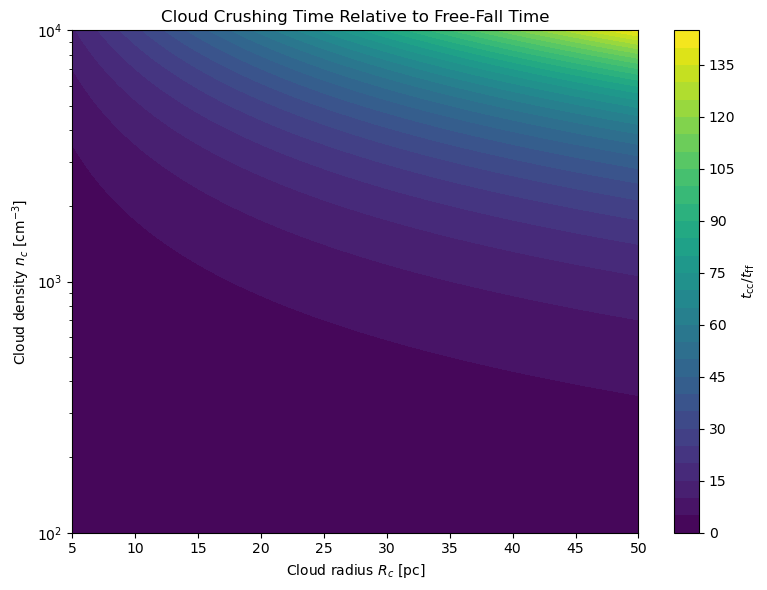

In [21]:
def freefall_time(n_cloud):
    rho_c = rho_from_n(n_cloud)
    return np.sqrt(3 * np.pi / (32 * G * rho_c))

R_vals = np.linspace(5, 50, 100)
n_vals = np.logspace(2, 4, 100)
R_grid, n_grid = np.meshgrid(R_vals, n_vals)

n_amb = 1.0
D_pc = 30.0
E_erg = 1e51

tcc_grid = cloud_crushing_time(R_grid, n_grid, n_amb, D_pc, E_erg)
tff_grid = freefall_time(n_grid)

ratio_grid = tcc_grid / tff_grid

plt.figure(figsize=(8, 6))
cont = plt.contourf(R_grid, n_grid, ratio_grid, levels=30)
plt.yscale("log")
plt.colorbar(cont, label=r"$t_{\rm cc}/t_{\rm ff}$")
plt.xlabel(r"Cloud radius $R_c$ [pc]")
plt.ylabel(r"Cloud density $n_c$ [cm$^{-3}$]")
plt.title(r"Cloud Crushing Time Relative to Free-Fall Time")
plt.tight_layout()
plt.show()

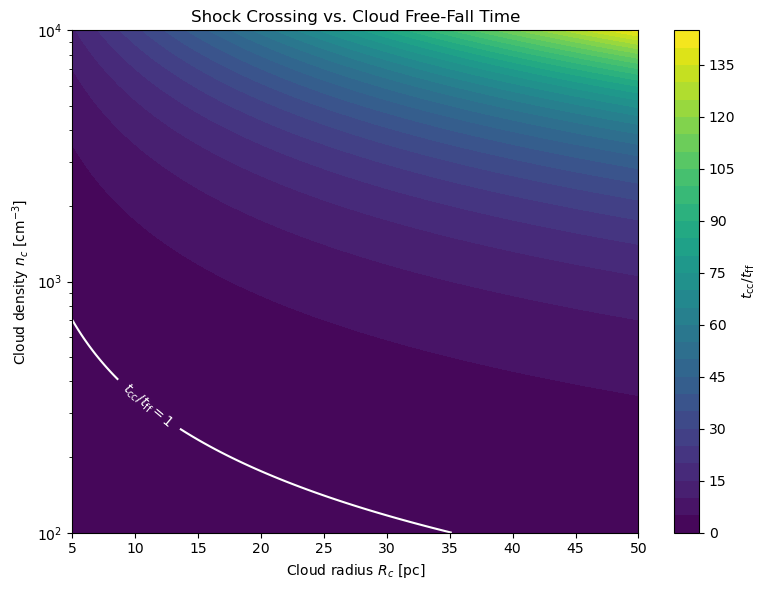

In [22]:
plt.figure(figsize=(8, 6))
cont = plt.contourf(R_grid, n_grid, ratio_grid, levels=30)
plt.yscale("log")
plt.colorbar(cont, label=r"$t_{\rm cc}/t_{\rm ff}$")

cs = plt.contour(R_grid, n_grid, ratio_grid, levels=[1], colors="white")
plt.clabel(cs, fmt={1: r"$t_{\rm cc}/t_{\rm ff}=1$"})

plt.xlabel(r"Cloud radius $R_c$ [pc]")
plt.ylabel(r"Cloud density $n_c$ [cm$^{-3}$]")
plt.title(r"Shock Crossing vs. Cloud Free-Fall Time")
plt.tight_layout()
plt.show()

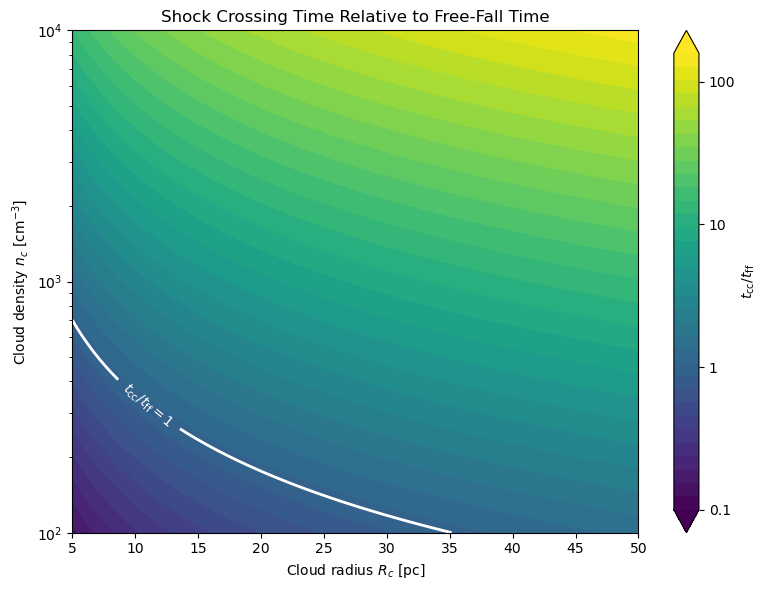

In [23]:
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker

plt.figure(figsize=(8, 6))

levels = np.logspace(-1, 2.2, 35)

cont = plt.contourf(
    R_grid, 
    n_grid, 
    ratio_grid, 
    levels=levels,
    norm=LogNorm(vmin=0.1, vmax=10**2.2),
    extend="both"
)

plt.yscale("log")

cbar = plt.colorbar(cont, label=r"$t_{\rm cc}/t_{\rm ff}$")
cbar.set_ticks([0.1, 1, 10, 100])
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))

cs = plt.contour(
    R_grid, 
    n_grid, 
    ratio_grid, 
    levels=[1], 
    colors="white",
    linewidths=2
)

plt.clabel(cs, fmt={1: r"$t_{\rm cc}/t_{\rm ff}=1$"}, colors="white")

plt.xlabel(r"Cloud radius $R_c$ [pc]")
plt.ylabel(r"Cloud density $n_c$ [cm$^{-3}$]")
plt.title(r"Shock Crossing Time Relative to Free-Fall Time")
plt.tight_layout()
plt.show()

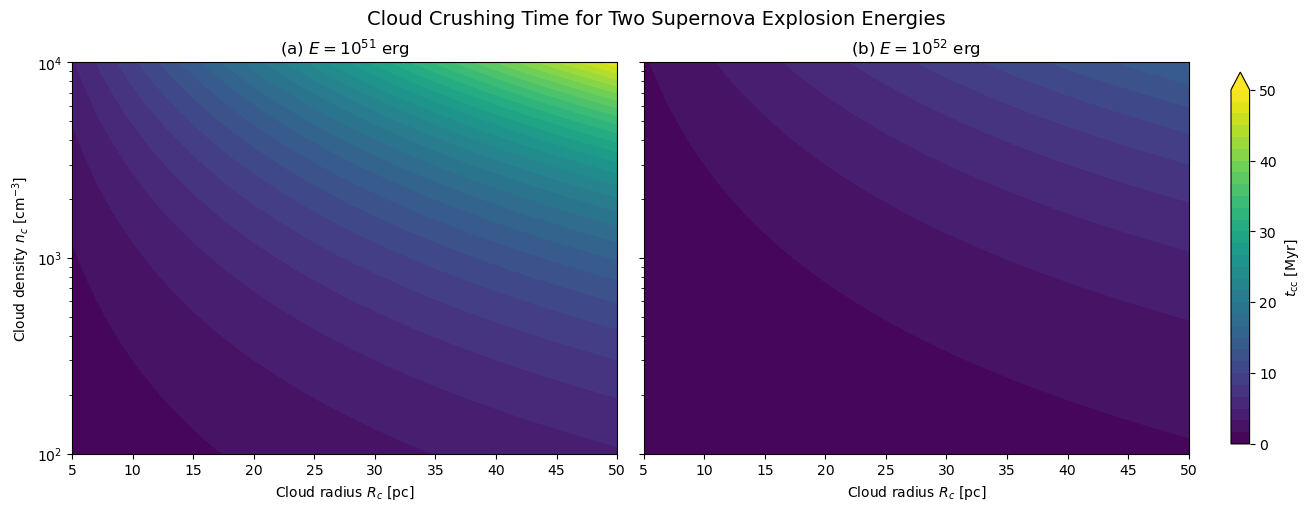

In [24]:
import numpy as np
import matplotlib.pyplot as plt

R_vals = np.linspace(5, 50, 100)             
n_vals = np.logspace(2, 4, 100)              
R_grid, n_grid = np.meshgrid(R_vals, n_vals)

n_amb = 1.0
D_pc = 30.0

E1 = 1e51
E2 = 1e52

tcc_E51 = cloud_crushing_time(R_grid, n_grid, n_amb, D_pc, E1) / Myr
tcc_E52 = cloud_crushing_time(R_grid, n_grid, n_amb, D_pc, E2) / Myr

levels = np.linspace(0, 50, 31)

fig, axes = plt.subplots(
    1, 2, 
    figsize=(13, 5), 
    sharey=True,
    constrained_layout=True
)

# left panel
cont = axes[0].contourf(
    R_grid,
    n_grid,
    tcc_E51,
    levels=levels,
    extend="max"
)

axes[0].set_yscale("log")
axes[0].set_xlabel(r"Cloud radius $R_c$ [pc]")
axes[0].set_ylabel(r"Cloud density $n_c$ [cm$^{-3}$]")
axes[0].set_title(r"(a) $E = 10^{51}$ erg")

# right panel
axes[1].contourf(
    R_grid,
    n_grid,
    tcc_E52,
    levels=levels,
    extend="max"
)

axes[1].set_yscale("log")
axes[1].set_xlabel(r"Cloud radius $R_c$ [pc]")
axes[1].set_title(r"(b) $E = 10^{52}$ erg")

cbar = fig.colorbar(
    cont,
    ax=axes,
    location="right",
    shrink=0.95,
    pad=0.03
)
cbar.set_ticks([0, 10, 20, 30, 40, 50])
cbar.set_label(r"$t_{\rm cc}$ [Myr]")

fig.suptitle(
    "Cloud Crushing Time for Two Supernova Explosion Energies",
    fontsize=14
)
plt.show()

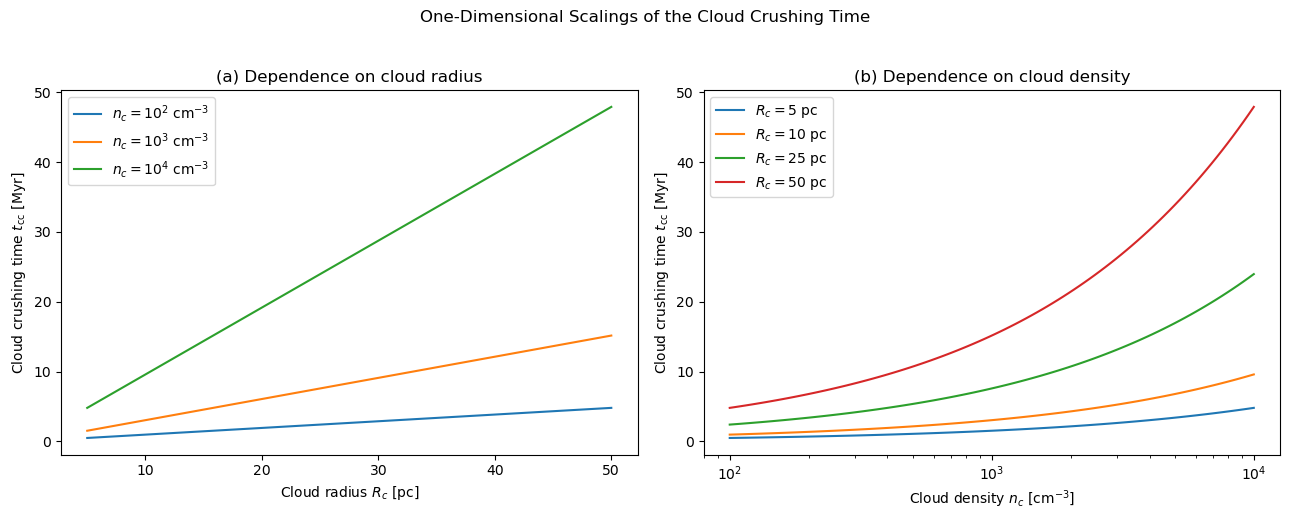

In [28]:
import numpy as np
import matplotlib.pyplot as plt

n_amb = 1.0
D_pc = 30.0
E_erg = 1e51

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left panel

R_vals = np.linspace(5, 50, 100)
n_cloud_list = [1e2, 1e3, 1e4]

for n_cloud in n_cloud_list:
    tcc_vals = cloud_crushing_time(R_vals, n_cloud, n_amb, D_pc, E_erg) / Myr
    axes[0].plot(
        R_vals,
        tcc_vals,
        label=rf"$n_c = 10^{{{int(np.log10(n_cloud))}}}$ cm$^{{-3}}$"
    )

axes[0].set_xlabel(r"Cloud radius $R_c$ [pc]")
axes[0].set_ylabel(r"Cloud crushing time $t_{\rm cc}$ [Myr]")
axes[0].set_title(r"(a) Dependence on cloud radius")
axes[0].legend()

# Right panel

n_vals = np.logspace(2, 4, 100)
R_cloud_list = [5, 10, 25, 50]

for R_c in R_cloud_list:
    tcc_vals = cloud_crushing_time(R_c, n_vals, n_amb, D_pc, E_erg) / Myr
    axes[1].plot(
        n_vals,
        tcc_vals,
        label=rf"$R_c = {R_c}$ pc"
    )

axes[1].set_xscale("log")
axes[1].set_xlabel(r"Cloud density $n_c$ [cm$^{-3}$]")
axes[1].set_ylabel(r"Cloud crushing time $t_{\rm cc}$ [Myr]")
axes[1].set_title(r"(b) Dependence on cloud density")
axes[1].legend()

fig.suptitle(r"One-Dimensional Scalings of the Cloud Crushing Time", y=1.03)

plt.tight_layout()
plt.show()

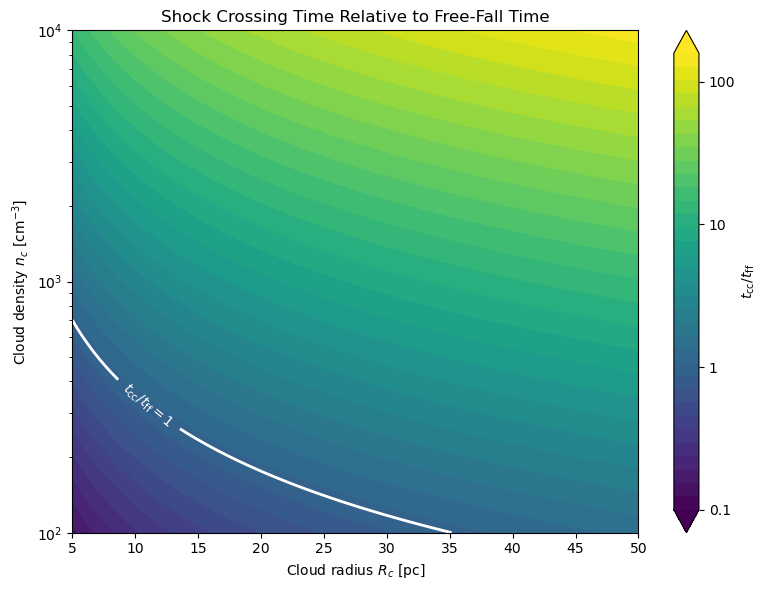

In [26]:
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker

R_vals = np.linspace(5, 50, 100)
n_vals = np.logspace(2, 4, 100)
R_grid, n_grid = np.meshgrid(R_vals, n_vals)

n_amb = 1.0
D_pc = 30.0
E_erg = 1e51

# calculate times
tcc_grid = cloud_crushing_time(R_grid, n_grid, n_amb, D_pc, E_erg)
tff_grid = freefall_time(n_grid)

ratio_grid = tcc_grid / tff_grid

plt.figure(figsize=(8, 6))

levels = np.logspace(-1, 2.2, 35)

cont = plt.contourf(
    R_grid,
    n_grid,
    ratio_grid,
    levels=levels,
    norm=LogNorm(vmin=0.1, vmax=10**2.2),
    extend="both"
)

plt.yscale("log")

cbar = plt.colorbar(cont, label=r"$t_{\rm cc}/t_{\rm ff}$")
cbar.set_ticks([0.1, 1, 10, 100])
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))

cs = plt.contour(
    R_grid,
    n_grid,
    ratio_grid,
    levels=[1],
    colors="white",
    linewidths=2
)

plt.clabel(
    cs,
    fmt={1: r"$t_{\rm cc}/t_{\rm ff}=1$"},
    colors="white"
)

plt.xlabel(r"Cloud radius $R_c$ [pc]")
plt.ylabel(r"Cloud density $n_c$ [cm$^{-3}$]")
plt.title(r"Shock Crossing Time Relative to Free-Fall Time")

plt.tight_layout()

plt.show()

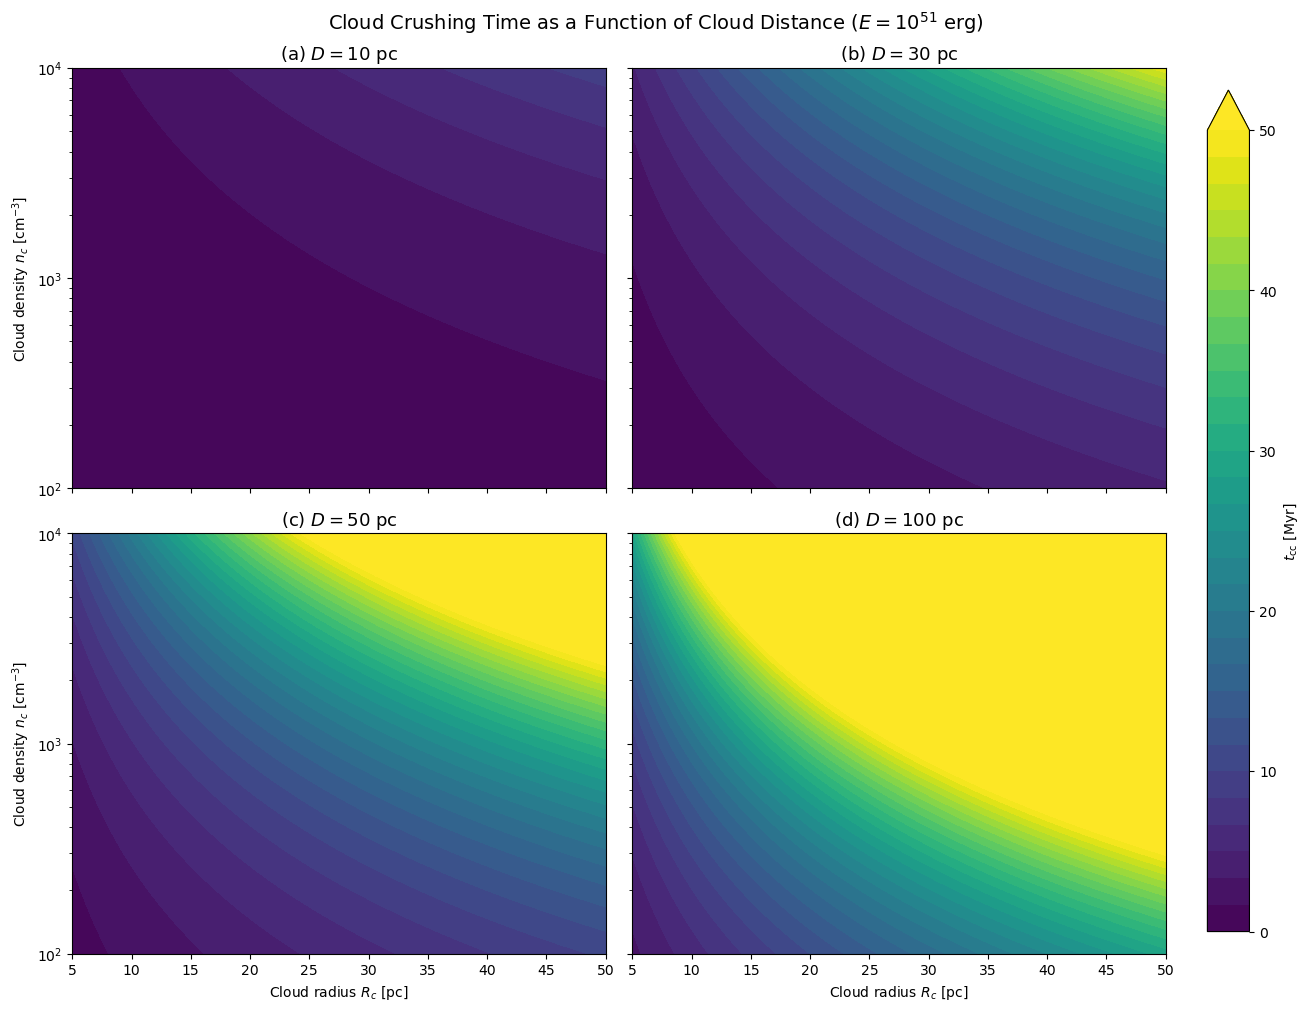

In [27]:
# Figure 4: Cloud crushing time varying cloud distance D

D_vals  = [10, 30, 50, 100]   # pc
labels  = [r"(a) $D = 10$ pc", r"(b) $D = 30$ pc",
           r"(c) $D = 50$ pc", r"(d) $D = 100$ pc"]

R_vals  = np.linspace(5, 50, 100)
n_vals  = np.logspace(2, 4, 100)
R_grid, n_grid = np.meshgrid(R_vals, n_vals)

n_amb  = 1.0
E_erg  = 1e51
levels = np.linspace(0, 50, 31)  

fig, axes = plt.subplots(2, 2, figsize=(13, 10),
                         sharey=True, sharex=True,
                         constrained_layout=True)
axes = axes.flatten()

for i, (D_pc, label) in enumerate(zip(D_vals, labels)):
    tcc_grid = cloud_crushing_time(R_grid, n_grid, n_amb, D_pc, E_erg) / Myr
    cont = axes[i].contourf(R_grid, n_grid, tcc_grid,
                             levels=levels, extend="max")
    axes[i].set_yscale("log")
    axes[i].set_title(label, fontsize=13)
    if i in [0, 2]:
        axes[i].set_ylabel(r"Cloud density $n_c$ [cm$^{-3}$]")
    if i in [2, 3]:
        axes[i].set_xlabel(r"Cloud radius $R_c$ [pc]")

cbar = fig.colorbar(cont, ax=axes, location="right", shrink=0.95, pad=0.03)
cbar.set_ticks([0, 10, 20, 30, 40, 50])
cbar.set_label(r"$t_{\rm cc}$ [Myr]")

fig.suptitle(
    r"Cloud Crushing Time as a Function of Cloud Distance ($E = 10^{51}$ erg)",
    fontsize=14
)

plt.show()